In [146]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
import requests
from io import StringIO
import yfinance as yf
from google import genai

plt.style.use('ggplot')

In [147]:


# header to avoid being blocked by wikipedia
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

response = requests.get(url, headers=headers)
tables = pd.read_html(StringIO(response.text))


raw_universe = tables[0][['Symbol', 'GICS Sector']].rename(columns={
    'GICS Sector': 'sector'
})
raw_universe['Symbol'] = raw_universe['Symbol'].str.replace('.', '-', regex=False)

universe = raw_universe.copy()
tickers = universe['Symbol'].tolist()

print(f'universe size: {len(universe)}')
print(universe['sector'].value_counts())

universe size: 503
sector
Industrials               80
Financials                76
Information Technology    74
Health Care               59
Consumer Discretionary    47
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21
Name: count, dtype: int64


In [148]:

end_date   = pd.Timestamp.today().strftime('%Y-%m-%d')
start_date = (pd.Timestamp.today() - pd.Timedelta(days=365)).strftime('%Y-%m-%d')

raw = yf.download(
    tickers + ['SPY'],
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=True
)

prices  = raw['Close']
volumes = raw['Volume']

# Mimic the per-ticker print from the original loop
for ticker in tickers + ['SPY']:
    if ticker in prices.columns:
        print(f'{ticker} DONE')
    else:
        print(f'{ticker} ERROR')
print(f'\nprices shape:  {prices.shape}')
print(f'volumes shape: {volumes.shape}')


[*********************100%***********************]  504 of 504 completed


MMM DONE
AOS DONE
ABT DONE
ABBV DONE
ACN DONE
ADBE DONE
AMD DONE
AES DONE
AFL DONE
A DONE
APD DONE
ABNB DONE
AKAM DONE
ALB DONE
ARE DONE
ALGN DONE
ALLE DONE
LNT DONE
ALL DONE
GOOGL DONE
GOOG DONE
MO DONE
AMZN DONE
AMCR DONE
AEE DONE
AEP DONE
AXP DONE
AIG DONE
AMT DONE
AWK DONE
AMP DONE
AME DONE
AMGN DONE
APH DONE
ADI DONE
AON DONE
APA DONE
APO DONE
AAPL DONE
AMAT DONE
APP DONE
APTV DONE
ACGL DONE
ADM DONE
ARES DONE
ANET DONE
AJG DONE
AIZ DONE
T DONE
ATO DONE
ADSK DONE
ADP DONE
AZO DONE
AVB DONE
AVY DONE
AXON DONE
BKR DONE
BALL DONE
BAC DONE
BAX DONE
BDX DONE
BRK-B DONE
BBY DONE
TECH DONE
BIIB DONE
BLK DONE
BX DONE
XYZ DONE
BNY DONE
BA DONE
BKNG DONE
BSX DONE
BMY DONE
AVGO DONE
BR DONE
BRO DONE
BF-B DONE
BLDR DONE
BG DONE
BXP DONE
CHRW DONE
CDNS DONE
CPT DONE
COF DONE
CAH DONE
CCL DONE
CARR DONE
CVNA DONE
CASY DONE
CAT DONE
CBOE DONE
CBRE DONE
CDW DONE
COR DONE
CNC DONE
CNP DONE
CF DONE
CRL DONE
SCHW DONE
CHTR DONE
CVX DONE
CMG DONE
CB DONE
CHD DONE
CIEN DONE
CI DONE
CINF DONE
CTAS DONE

In [149]:
prices = prices.sort_index()
volumes = volumes.sort_index()

prices = prices.apply(pd.to_numeric, errors='coerce')
volumes = volumes.apply(pd.to_numeric, errors='coerce')

prices = prices.ffill(limit=3)

returns = prices.pct_change(fill_method=None)
returns = returns.iloc[1:]

missing_pct = returns.isna().mean()

valid_tickers = missing_pct[missing_pct <= 0.10].index.tolist()

if 'SPY' not in valid_tickers:
    valid_tickers.append('SPY')

returns = returns[valid_tickers]
volumes = volumes[valid_tickers]

spy_returns = returns['SPY']
stock_returns = returns.drop(columns=['SPY'])

stock_returns.head()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-01,0.022826,0.012916,0.023543,0.023198,0.001838,0.004942,0.012479,0.013493,0.011007,0.031641,...,0.021409,0.088502,0.008957,0.013358,0.012678,0.005005,0.014780,0.031247,0.023090,0.020776
2025-07-02,0.001743,0.022231,0.004000,-0.000148,-0.015779,-0.034098,-0.001090,-0.034762,0.018742,0.026630,...,0.017530,0.026677,-0.016737,0.016569,0.005420,0.013915,-0.001264,-0.005954,0.015564,-0.000691
2025-07-03,0.005967,0.005225,-0.007706,0.008125,0.002461,0.009165,0.008237,0.002219,0.002162,-0.010555,...,-0.010112,0.009075,0.009325,0.010356,0.004328,0.000144,-0.001198,0.001818,0.010394,0.000629
2025-07-07,-0.017548,-0.016858,-0.008717,0.003736,-0.005504,0.002579,-0.013912,-0.006275,-0.015752,-0.014283,...,-0.029890,0.028780,-0.004546,-0.009715,-0.009677,0.002600,0.002400,-0.011743,-0.020419,-0.013381
2025-07-08,0.014759,0.000286,0.011405,-0.000073,-0.002543,0.008835,0.009283,0.014087,0.013813,0.000550,...,0.020671,0.016472,-0.004714,0.027720,0.003130,-0.022619,0.001131,0.009722,0.018763,0.004775


In [150]:
stock_returns.shape

(249, 501)

In [151]:
window = 60

rolling_beta = pd.DataFrame(np.nan, index=stock_returns.index, columns=stock_returns.columns)
rolling_alpha = pd.DataFrame(np.nan, index=stock_returns.index, columns=stock_returns.columns)

spy_with_const = sm.add_constant(spy_returns)

for ticker in stock_returns.columns:
    model = RollingOLS(stock_returns[ticker], spy_with_const, window=window).fit()
    rolling_beta[ticker] = model.params['SPY']
    rolling_alpha[ticker] = model.params['const']

print(f'beta estimated for: {rolling_beta.notna().any().sum()} tickers')
print(f'date range with estimates: {rolling_beta.dropna(how="all").index[0].date()} to {rolling_beta.dropna(how="all").index[-1].date()}')

beta estimated for: 501 tickers
date range with estimates: 2025-09-24 to 2026-06-26


In [152]:
rolling_beta.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-22,1.009497,0.738239,-0.118412,1.221760,0.250176,-0.226011,-0.145610,0.239226,1.645788,-0.187824,...,0.446403,1.030831,0.052743,-1.098833,0.867169,2.058874,0.160091,0.295792,1.552022,0.707474
2026-06-23,1.042936,0.785376,-0.115687,1.235212,0.153304,-0.255349,-0.119352,0.262977,1.845523,-0.139997,...,0.424049,0.950024,0.005017,-1.101083,0.856647,2.093314,0.076217,0.349210,1.613812,0.686223
2026-06-24,0.978149,0.773875,-0.162755,1.056237,0.150315,-0.310481,-0.192098,0.197137,1.882068,-0.153110,...,0.474238,0.906308,0.002563,-1.031303,0.851319,1.986173,0.023265,0.329574,1.663411,0.637679
2026-06-25,0.993709,0.779946,-0.152943,1.066749,0.122370,-0.283647,-0.151545,0.236196,1.870153,-0.167276,...,0.492885,0.922799,0.017249,-1.032711,0.833711,2.021259,0.030990,0.330216,1.655432,0.679232
2026-06-26,1.034824,0.662768,-0.368743,1.026192,0.062218,-0.420476,-0.304386,0.092058,2.034974,-0.267755,...,0.572095,0.733200,-0.007311,-1.127351,0.789058,1.902322,-0.074925,0.191820,1.550182,0.673858


In [153]:
rolling_alpha.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-22,0.000112,0.001217,0.002285,-0.001563,-0.003237,0.000356,-0.006069,-0.003364,0.002252,0.001706,...,-0.000300,-0.001720,0.000350,-0.000036,-0.003111,-0.000806,-0.001079,-0.000486,-0.000199,-0.007967
2026-06-23,-0.000069,0.000901,0.002313,-0.001607,-0.002481,0.000594,-0.006187,-0.003469,0.000730,0.001356,...,-0.000109,-0.001115,0.000726,-0.000040,-0.003031,-0.000979,-0.000489,-0.000817,-0.000642,-0.007738
2026-06-24,0.000934,0.000913,0.002608,0.000208,-0.002431,0.001142,-0.005366,-0.003031,0.000688,0.001283,...,0.000050,-0.000850,0.000933,-0.000808,-0.002736,0.000425,0.000012,-0.000187,-0.000362,-0.007049
2026-06-25,0.001039,-0.000038,0.002885,-0.000226,-0.001526,0.000601,-0.006314,-0.003862,0.000996,0.001767,...,-0.000026,-0.001698,0.000721,-0.000690,-0.001826,-0.000489,-0.000283,-0.000106,-0.000495,-0.007720
2026-06-26,0.001289,0.000705,0.003579,0.000502,-0.001305,0.001204,-0.005746,-0.002765,-0.000264,0.001701,...,-0.000279,-0.001409,0.000821,-0.001073,-0.001788,0.000890,0.000431,0.000375,0.000455,-0.007939


In [154]:
beta_shifted = rolling_beta.shift(1)
alpha_shifted = rolling_alpha.shift(1)

spy_aligned = spy_returns.reindex(stock_returns.index)

expected_returns = alpha_shifted.add(beta_shifted.multiply(spy_aligned, axis=0))
residuals = stock_returns - expected_returns

In [155]:
expected_returns.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-22,-0.003254,-0.001076,0.001445,-0.004912,-0.003844,0.000855,-0.005186,-0.004242,-0.003697,0.002031,...,-0.001646,-0.004843,-0.000265,0.003302,-0.005916,-0.007057,-0.001456,-0.001038,-0.006156,-0.009482
2026-06-23,-0.014548,-0.009503,0.004005,-0.019306,-0.006870,0.003639,-0.003955,-0.006838,-0.021648,0.004434,...,-0.006783,-0.016689,-0.000416,0.015921,-0.015704,-0.030705,-0.003403,-0.004782,-0.022738,-0.018241
2026-06-24,-0.000552,0.000537,0.002366,-0.002180,-0.002552,0.000712,-0.006131,-0.003591,-0.000125,0.001421,...,-0.000306,-0.001556,0.000723,0.000471,-0.003428,-0.001949,-0.000524,-0.000979,-0.001390,-0.008057
2026-06-25,0.002348,0.002032,0.002373,0.001735,-0.002214,0.000693,-0.005644,-0.002746,0.003408,0.001062,...,0.000736,0.000460,0.000936,-0.002299,-0.001505,0.003296,0.000045,0.000289,0.002042,-0.006127
2026-06-26,-0.006147,-0.005679,0.003991,-0.007940,-0.002411,0.002652,-0.005218,-0.005570,-0.012528,0.002977,...,-0.003590,-0.008371,0.000596,0.006778,-0.007855,-0.015106,-0.000507,-0.002494,-0.012466,-0.012632


In [156]:
residuals.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-22,-0.001232,-0.002280,0.061006,-0.017699,-0.002716,0.008577,-0.019427,0.002910,0.029062,0.013815,...,-0.001233,-0.013256,0.018350,0.001487,0.009057,-0.015810,-0.006768,-0.008966,0.047303,-0.026345
2026-06-23,0.015971,0.000379,0.016647,0.016863,0.037612,0.014506,0.021419,0.019819,-0.064147,-0.010332,...,0.014618,0.021804,0.019703,-0.006822,0.003447,0.021125,0.009109,0.010293,-0.009701,0.030759
2026-06-24,0.039709,-0.004682,-0.001813,0.042151,0.002110,0.012200,0.022980,-0.000765,0.014612,-0.011442,...,0.035494,-0.002285,0.013468,-0.020724,0.018283,0.047687,0.009891,0.035123,0.043709,0.025365
2026-06-25,0.027129,-0.063210,0.032750,-0.019186,0.032604,-0.006909,-0.020140,-0.013330,0.008137,0.018384,...,0.017446,-0.042581,0.002501,0.007047,0.045775,-0.024438,-0.012331,0.006797,-0.019760,0.001650
2026-06-26,0.009836,0.037043,0.038002,0.033877,0.011849,0.031377,0.030333,0.053758,-0.061695,0.000289,...,-0.013879,0.019037,0.005275,-0.014121,0.003154,0.065592,0.035376,0.026021,0.045910,-0.009599


In [157]:
window_z = 20

resid_mean = residuals.shift(1).rolling(window_z).mean()
resid_std = residuals.shift(1).rolling(window_z).std()

zscore = (residuals - resid_mean) / resid_std

zscore.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-22,-0.166448,-0.005005,3.554490,-1.227070,-0.419799,0.691442,-0.127599,0.375244,0.977394,1.012679,...,-0.258490,-0.842642,1.274212,0.529684,0.409838,-0.834558,-0.524562,-0.824016,2.117942,-1.821049
2026-06-23,0.273724,0.206026,0.591446,0.722907,2.057832,1.022147,0.741082,0.803395,-2.674106,-0.379006,...,0.720203,0.800530,1.271792,0.018176,-0.118631,0.818329,0.566961,0.479244,-0.409642,1.284161
2026-06-24,0.841627,-0.113014,-0.298512,2.090357,-0.221842,0.809987,0.754297,0.192559,0.450490,-0.403010,...,1.903766,-0.375608,0.812394,-0.776247,1.326176,2.034985,0.603223,2.064229,2.009273,0.958998
2026-06-25,0.469164,-4.176155,1.303239,-1.416763,1.481208,-0.475452,-0.173100,-0.182984,0.307172,1.259657,...,0.693457,-2.196468,0.058821,0.846054,3.691423,-1.456377,-0.896020,0.064922,-0.844397,-0.295156
2026-06-26,0.025117,2.219211,1.446867,1.344877,0.187509,2.306534,0.879892,1.703735,-2.209374,0.272359,...,-0.998405,0.747045,0.235586,-0.481657,-0.298471,2.650650,2.186932,1.234947,1.834303,-0.852382


In [158]:
residuals_3d = (1 + residuals).rolling(3).apply(np.prod, raw=True) - 1
residuals_5d = (1 + residuals).rolling(5).apply(np.prod, raw=True) - 1

print('3-day compounded residuals (last 5 rows, first 5 tickers):')
print(residuals_3d.iloc[-5:, :5].round(4))
print('\n5-day compounded residuals (last 5 rows, first 5 tickers):')
print(residuals_5d.iloc[-5:, :5].round(4))

3-day compounded residuals (last 5 rows, first 5 tickers):
Ticker           A    AAPL    ABBV    ABNB     ABT
Date                                              
2026-06-22 -0.0102 -0.0075  0.0287 -0.0031 -0.0213
2026-06-23  0.0267 -0.0039  0.0541  0.0009  0.0342
2026-06-24  0.0550 -0.0066  0.0767  0.0410  0.0370
2026-06-25  0.0850 -0.0672  0.0480  0.0394  0.0737
2026-06-26  0.0784 -0.0331  0.0701  0.0568  0.0470

5-day compounded residuals (last 5 rows, first 5 tickers):
Ticker           A    AAPL    ABBV    ABNB     ABT
Date                                              
2026-06-22 -0.0340  0.0091  0.0004  0.0543  0.0099
2026-06-23 -0.0076  0.0054  0.0483  0.0399  0.0430
2026-06-24  0.0455 -0.0118  0.0439  0.0564  0.0176
2026-06-25  0.0965 -0.0712  0.0866  0.0230  0.0702
2026-06-26  0.0943 -0.0349  0.1542  0.0556  0.0835


In [159]:
vol_mean = volumes.shift(1).rolling(20).mean()
volume_ratio = volumes / vol_mean

volume_ratio = volume_ratio.drop(columns=['SPY'], errors='ignore')

print('volume ratios (last 5 rows, first 5 tickers):')
print(volume_ratio.iloc[-5:, :5].round(2))

volume ratios (last 5 rows, first 5 tickers):
Ticker         A  AAPL  ABBV  ABNB   ABT
Date                                    
2026-06-22  0.78  0.85  1.81  1.10  0.83
2026-06-23  0.76  0.98  1.28  0.89  0.88
2026-06-24  0.91  1.00  1.25  1.04  0.94
2026-06-25  0.73  2.00  1.71  0.77  1.18
2026-06-26  1.15  4.65  8.38  1.55  1.14


In [160]:
scan_date = stock_returns.index[-1]

queue = pd.DataFrame({
    'sector': universe.set_index('Symbol')['sector'],
    'actual_return': stock_returns.loc[scan_date],
    'spy_return': spy_returns.loc[scan_date],
    'beta': beta_shifted.loc[scan_date],
    'expected_return': expected_returns.loc[scan_date],
    'residual': residuals.loc[scan_date],
    'zscore': zscore.loc[scan_date],
    'residual_3d': residuals_3d.loc[scan_date],
    'residual_5d': residuals_5d.loc[scan_date],
    'volume_ratio': volume_ratio.loc[scan_date]
})

queue = queue.dropna()
queue = queue.reindex(queue['zscore'].abs().sort_values(ascending=False).index)
queue['high_confidence'] = (queue['zscore'].abs() > 2.0) & (queue['volume_ratio'] > 1.5)

queue.head(10)

,sector,actual_return,spy_return,beta,expected_return,residual,zscore,residual_3d,residual_5d,volume_ratio,high_confidence
ON,Information Technology,-0.236567,-0.007231,3.465621,-0.020161,-0.216407,-5.148496,-0.214357,-0.205987,3.708471,True
TROW,Financials,0.036957,-0.007231,0.644934,-0.003103,0.040060,3.915528,0.039633,0.029895,1.717340,True
BIIB,Health Care,0.069667,-0.007231,-0.051437,0.001957,0.067710,3.649629,0.091148,0.092112,2.163334,True
STX,Information Technology,-0.122357,-0.007231,2.397807,-0.005289,-0.117068,-3.595662,-0.150129,-0.157741,2.214346,True
LLY,Health Care,0.071323,-0.007231,0.508759,-0.000703,0.072026,3.509835,0.085442,0.101760,2.352690,True
PYPL,Financials,0.045068,-0.007231,0.916628,-0.009631,0.054699,3.495102,0.076951,0.078141,1.980853,True
EME,Industrials,-0.074838,-0.007231,1.650820,-0.012473,-0.062365,-3.470477,-0.034880,-0.001263,3.258488,True
KEYS,Information Technology,-0.087208,-0.007231,1.605013,-0.010637,-0.076570,-3.445743,-0.059025,-0.063040,3.576115,True
FDS,Financials,0.109653,-0.007231,-0.173716,0.002646,0.107007,3.256040,0.054076,0.027181,1.573463,True
NFLX,Communication Services,0.041044,-0.007231,0.308633,-0.007309,0.048353,3.144711,0.030115,-0.020085,1.635154,True


In [161]:
from google.colab import userdata
api_key = userdata.get('eodhd_api_key')
print(api_key)
def fetch_news(ticker, start, end):
    url = f'https://eodhd.com/api/news?s={ticker}.US&from={start}&to={end}&limit=3&api_token={api_key}&fmt=json'
    r = requests.get(url)
    data = r.json()
    return [item['title'] for item in data[:3]]

news_start = (scan_date - pd.Timedelta(days=3)).strftime('%Y-%m-%d')
news_end = scan_date.strftime('%Y-%m-%d')

high_conf = queue[queue['high_confidence']].head(10)
remaining = queue[~queue['high_confidence']].head(max(0, 10 - len(high_conf)))
news_candidates = pd.concat([high_conf, remaining])

news_results = {}
for ticker in news_candidates.index:
    headlines = fetch_news(ticker, news_start, news_end)
    news_results[ticker] = headlines
    print(f'\n{ticker}:')
    if headlines:
        for h in headlines:
            print(f'  - {h}')
    else:
        print('  no news found')

6a423c8a7fceb6.53712468

ON:
  - Stock Indexes Finish Lower as Chipmakers Sell Off
  - Here's Why ON Semiconductor Corp. (ON) Fell More Than Broader Market
  - Why onsemi (ON) Shares Are Falling Today

TROW:
  - T. Rowe Price Sees Yuan Falling 1%--2% by Year-End
  - Is T. Rowe Price Personal Strategy Balanced (TRPBX) a Strong Mutual Fund Pick Right Now?
  - What Rising Structural Inflation Means for Your Bond Portfolio

BIIB:
  - Why Biogen (BIIB) Stock Is Up Today
  - Lilly, J&amp;J and AbbVie Hit New Highs
  - Lilly, J&amp;J, AbbVie hit new 52-week highs as healthcare outperforms

STX:
  - Stock Indexes Finish Lower as Chipmakers Sell Off
  - Stock Market Today, June 26: Sandisk Tumbles and Tech Weakness Weighs on Markets
  - Stocks making big moves this week: Qualcomm, Accenture, 10x Genomics, Seagate, and Lattice Semiconductor

LLY:
  - Why Eli Lilly Stock Jumped to a New All-Time High Today
  - Why Eli Lilly Stock Jumped to a New All-Time High Today
  - Why Is Eli Lilly (LLY) Stoc

In [162]:
bullish = queue[queue['high_confidence'] & (queue['zscore'] > 0)]
bearish = queue[queue['high_confidence'] & (queue['zscore'] < 0)]

bullish_leaderboard = bullish.groupby('sector').agg(
    signal_count=('high_confidence', 'count'),
    avg_zscore=('zscore', 'mean'),
    avg_volume_ratio=('volume_ratio', 'mean')
).sort_values('avg_zscore', ascending=False)

bearish_leaderboard = bearish.groupby('sector').agg(
    signal_count=('high_confidence', 'count'),
    avg_zscore=('zscore', 'mean'),
    avg_volume_ratio=('volume_ratio', 'mean')
).sort_values('avg_zscore', ascending=True)

print("BULLISH SECTORS")
print(bullish_leaderboard)
print("\nBEARISH SECTORS")
print(bearish_leaderboard)

BULLISH SECTORS
                        signal_count  avg_zscore  avg_volume_ratio
sector                                                            
Communication Services             1    3.144711          1.635154
Financials                         7    2.873344          2.063134
Health Care                        8    2.641807          2.006140
Industrials                        1    2.594357          2.890941
Consumer Discretionary             2    2.317167          3.300930
Information Technology             4    2.299346          3.110178
Real Estate                        1    2.022967          2.196146

BEARISH SECTORS
                        signal_count  avg_zscore  avg_volume_ratio
sector                                                            
Information Technology             6   -3.249957          2.914962
Industrials                        6   -2.584870          3.055075
Financials                         2   -2.184498          1.594108


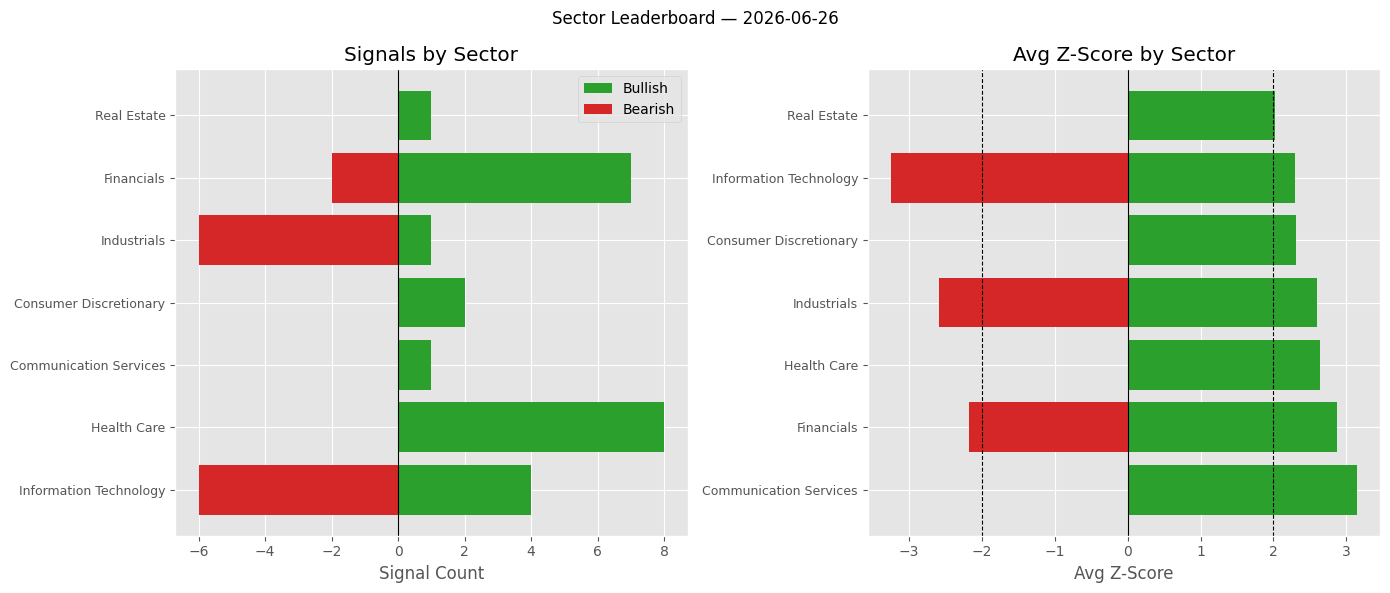

In [163]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

all_sectors = list(set(bullish_leaderboard.index) | set(bearish_leaderboard.index))
bull_counts = [bullish_leaderboard.loc[s, 'signal_count'] if s in bullish_leaderboard.index else 0 for s in all_sectors]
bear_counts = [-bearish_leaderboard.loc[s, 'signal_count'] if s in bearish_leaderboard.index else 0 for s in all_sectors]

y = np.arange(len(all_sectors))
ax1.barh(y, bull_counts, color='#2ca02c', label='Bullish')
ax1.barh(y, bear_counts, color='#d62728', label='Bearish')
ax1.set_yticks(y)
ax1.set_yticklabels(all_sectors, fontsize=9)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Signal Count')
ax1.set_title('Signals by Sector')
ax1.legend()

bull_z = bullish_leaderboard['avg_zscore'].values
bear_z = bearish_leaderboard['avg_zscore'].values
z_labels = list(bullish_leaderboard.index) + list(bearish_leaderboard.index)
z_scores = list(bull_z) + list(bear_z)
z_colors = ['#2ca02c' if z > 0 else '#d62728' for z in z_scores]

ax2.barh(z_labels, z_scores, color=z_colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axvline(2.0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(-2.0, color='black', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Avg Z-Score')
ax2.set_title('Avg Z-Score by Sector')
ax2.tick_params(axis='y', labelsize=9)

plt.suptitle(f'Sector Leaderboard — {scan_date.date()}', fontsize=12)
plt.tight_layout()
plt.show()

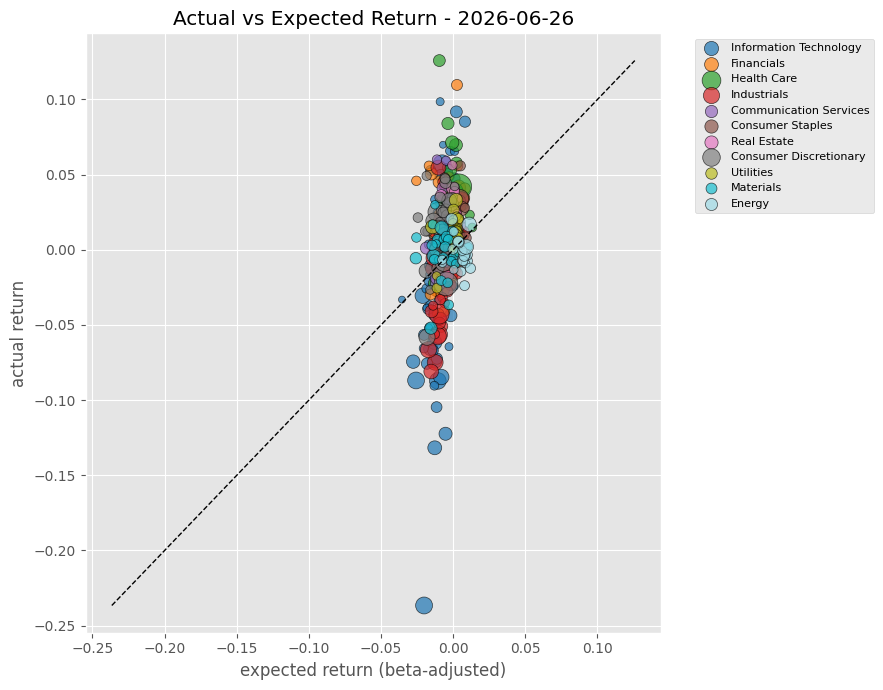

In [164]:
fig, ax = plt.subplots(figsize=(9, 7))

sector_list = queue['sector'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(sector_list)))
sector_colors = dict(zip(sector_list, colors))

for sector in sector_list:
    subset = queue[queue['sector'] == sector]
    ax.scatter(
        subset['expected_return'], subset['actual_return'],
        s=subset['volume_ratio'] * 40,
        color=sector_colors[sector],
        label=sector, alpha=0.7, edgecolors='black', linewidth=0.5
    )

lims = [queue[['expected_return', 'actual_return']].min().min(),
        queue[['expected_return', 'actual_return']].max().max()]
ax.plot(lims, lims, color='black', linestyle='--', linewidth=1)

ax.set_xlabel('expected return (beta-adjusted)')
ax.set_ylabel('actual return')
ax.set_title(f'Actual vs Expected Return - {scan_date.date()}')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

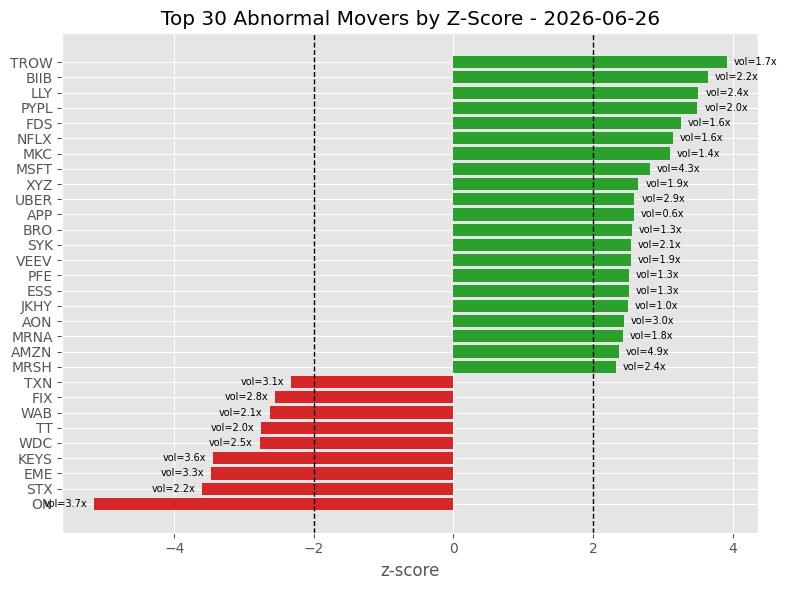

In [165]:
top30 = queue.head(30).sort_values('zscore')

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = ['#2ca02c' if z > 0 else '#d62728' for z in top30['zscore']]
ax.barh(top30.index, top30['zscore'], color=bar_colors)

for i, (ticker, row) in enumerate(top30.iterrows()):
    ax.text(row['zscore'] + (0.1 if row['zscore'] > 0 else -0.1),
             i, f'vol={row["volume_ratio"]:.1f}x',
             va='center', ha='left' if row['zscore'] > 0 else 'right', fontsize=7)

ax.axvline(2.0, color='black', linestyle='--', linewidth=1)
ax.axvline(-2.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('z-score')
ax.set_title(f'Top 30 Abnormal Movers by Z-Score - {scan_date.date()}')
plt.tight_layout()
plt.show()

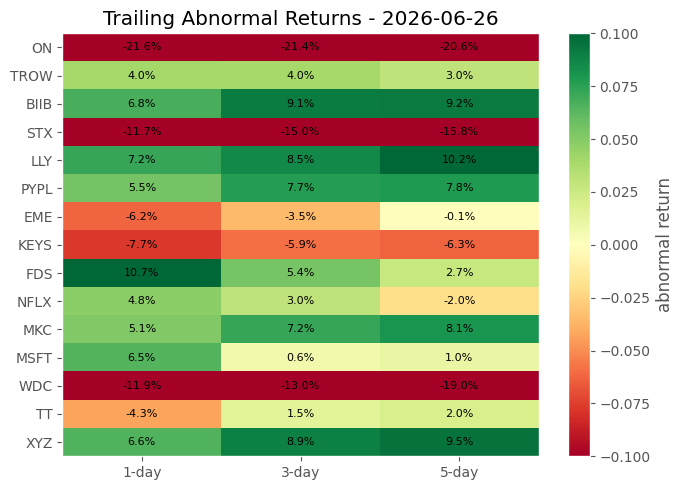

In [166]:
top15 = queue.head(15)
heatmap_data = top15[['residual', 'residual_3d', 'residual_5d']]
heatmap_data.columns = ['1-day', '3-day', '5-day']

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.grid(False)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(j, i, f'{heatmap_data.values[i, j]:.1%}', ha='center', va='center', fontsize=8)

ax.set_title(f'Trailing Abnormal Returns - {scan_date.date()}')
plt.colorbar(im, ax=ax, label='abnormal return')
plt.tight_layout()
plt.show()

In [167]:
import time
client = genai.Client(api_key=userdata.get('gemini_api_key'))

high_conf_tickers = queue[queue['high_confidence']].head(10).index.tolist()
print(f"high confidence stocks: {len(high_conf_tickers)}")

llm_results = {}
for ticker in high_conf_tickers:

    if ticker in llm_results:
        continue

    headlines = news_results.get(ticker, [])

    if not headlines:
        llm_results[ticker] = 'NO'
        print(f"{ticker}: NO (no news)")
        continue

    headlines_text = '\n'.join(f'- {h}' for h in headlines)

    prompt = f"""You are a financial analyst.
Stock: {ticker}
Z-Score: {queue.loc[ticker, 'zscore']:.2f}
Volume Ratio: {queue.loc[ticker, 'volume_ratio']:.2f}x
Recent Headlines:
{headlines_text}

Is the news sentiment positive for this stock?
Reply YES or NO only. No explanation."""

    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=prompt
        )
        answer = response.text.strip().upper()
        llm_results[ticker] = 'YES' if 'YES' in answer else 'NO'
        print(f"{ticker}: {llm_results[ticker]}")
        time.sleep(13)  # per req in 13 sec to avoid rate limit

    except Exception as e:
        print(f"{ticker}: skipped — {e}")
        llm_results[ticker] = 'NO'

# Step 3 — store only YES stocks
confirmed_tickers = [t for t, ans in llm_results.items() if ans == 'YES']
confirmed_stocks = queue.loc[confirmed_tickers]

high confidence stocks: 10
ON: NO
TROW: YES
BIIB: YES
STX: NO
LLY: YES
PYPL: NO
EME: NO
KEYS: YES
FDS: YES
NFLX: YES


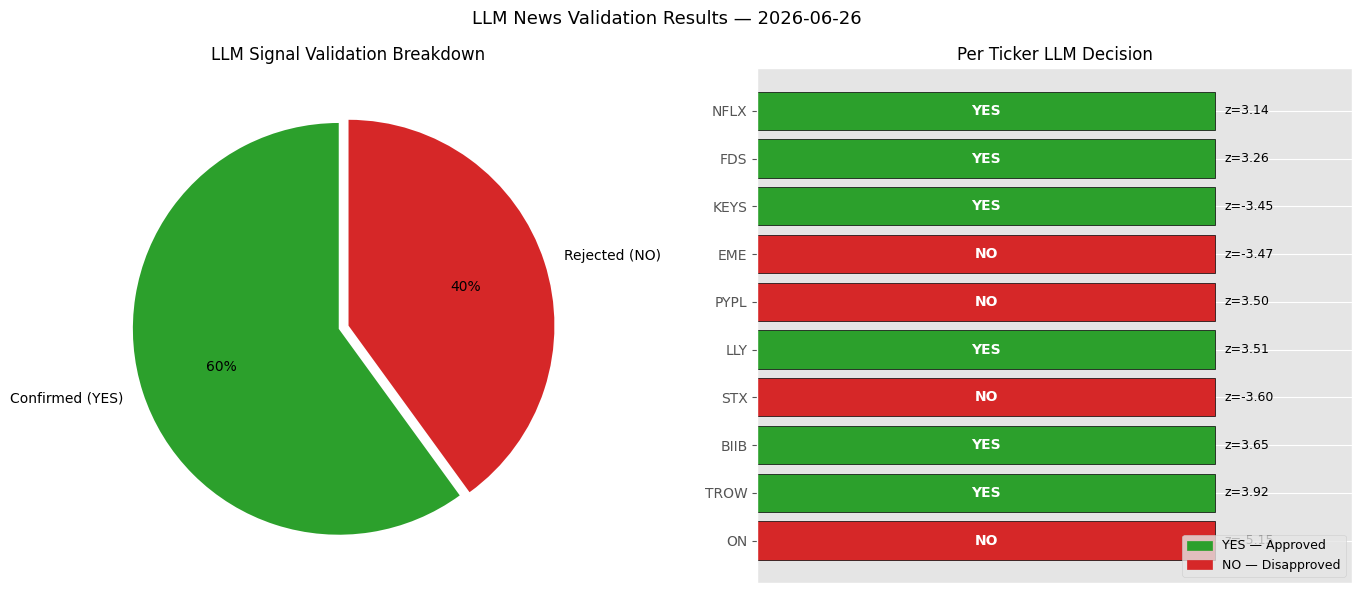

In [168]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

yes_count = sum(1 for v in llm_results.values() if v == 'YES')
no_count = sum(1 for v in llm_results.values() if v == 'NO')
skipped_count = len(high_conf_tickers) - len(llm_results)

labels = ['Confirmed (YES)', 'Rejected (NO)', 'Skipped']
sizes = [yes_count, no_count, skipped_count]
colors = ['#2ca02c', '#d62728', '#aec7e8']
explode = [0.05, 0, 0]

filtered = [(l, s, c, e) for l, s, c, e in zip(labels, sizes, colors, explode) if s > 0]
labels, sizes, colors, explode = zip(*filtered)

axes[0].pie(sizes, labels=labels, colors=colors, explode=explode,
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
axes[0].set_title('LLM Signal Validation Breakdown', fontsize=12)

tickers = list(llm_results.keys())
bar_colors = ['#2ca02c' if llm_results[t] == 'YES' else '#d62728' for t in tickers]
y_pos = range(len(tickers))

axes[1].barh(y_pos, [1] * len(tickers), color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(tickers, fontsize=10)
axes[1].set_xticks([])
axes[1].set_title('Per Ticker LLM Decision', fontsize=12)

for i, ticker in enumerate(tickers):
    decision = llm_results[ticker]
    axes[1].text(0.5, i, decision, ha='center', va='center',
                 fontsize=10, fontweight='bold', color='white')

for i, ticker in enumerate(tickers):
    if ticker in queue.index:
        z = queue.loc[ticker, 'zscore']
        axes[1].text(1.02, i, f'z={z:.2f}', va='center', fontsize=9, color='black')

axes[1].set_xlim(0, 1.3)

yes_patch = mpatches.Patch(color='#2ca02c', label='YES — Approved')
no_patch = mpatches.Patch(color='#d62728', label='NO — Disapproved')
axes[1].legend(handles=[yes_patch, no_patch], loc='lower right', fontsize=9)

plt.suptitle(f'LLM News Validation Results — {scan_date.date()}', fontsize=13)
plt.tight_layout()
plt.show()